# Task 1: Purchase Prediction Model Evaluation

This notebook evaluates the trained Random Forest reorder prediction model using comprehensive metrics and visualizations.

## 1. Setup and Imports

In [14]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, auc, roc_curve
from sklearn.preprocessing import label_binarize

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / "src"))

from evaluate import (
    compute_metrics,
    evaluate_model,
    get_confusion_matrix,
    print_full_report,
)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 10

print("✓ Imports successful")

✓ Imports successful


## 2. Load Saved Model and Test Data

In [15]:
# Define paths
BASE_DIR = Path.cwd().parent
MODEL_PATH = BASE_DIR / "models" / "reorder_model.pkl"
CLASS_NAMES_PATH = BASE_DIR / "models" / "class_names.pkl"
ORDERS_PATH = BASE_DIR / "data" / "raw" / "orders.csv"
PRODUCTS_PATH = BASE_DIR / "data" / "raw" / "products.csv"

# Check if model exists
if not MODEL_PATH.exists():
    print(f"❌ Model not found at {MODEL_PATH}")
    print("Please train the model first using: python -m task1_purchase_prediction.src.model")
else:
    print(f"✓ Model found at {MODEL_PATH}")
    
# Load model
model = joblib.load(MODEL_PATH)
print(f"✓ Model loaded: {type(model).__name__}")
print(f"  - n_estimators: {model.n_estimators}")
print(f"  - max_depth: {model.max_depth}")
print(f"  - Number of features: {model.n_features_in_}")

✓ Model found at c:\Users\Konstantinos\Documents\GitHub\UFCFUR-15-3---Advanced-artificial-intelligence\task1_purchase_prediction\models\reorder_model.pkl
✓ Model loaded: RandomForestClassifier
  - n_estimators: 200
  - max_depth: 12
  - Number of features: 24


## 3. Run Model Evaluation

In [16]:
# Run comprehensive evaluation
metrics, y_test, y_pred, y_proba = evaluate_model(
    model_path=MODEL_PATH,
    orders_path=ORDERS_PATH,
    products_path=PRODUCTS_PATH,
    test_size=0.2,
    random_state=42,
    verbose=True,
)


MODEL EVALUATION RESULTS
Test samples: 497
Number of classes: 12

Metrics Summary:
--------------------------------------------------------------------------------
ACCURACY...................... 0.0885
PRECISION..................... 0.0929
RECALL........................ 0.0885
F1............................ 0.0879
ROC_AUC....................... 0.5322

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Apples     0.0851    0.0755    0.0800        53
       Bread     0.1707    0.1148    0.1373        61
     Carrots     0.0606    0.0476    0.0533        42
      Cheese     0.1111    0.1316    0.1205        38
   Croissant     0.1707    0.2692    0.2090        26
     Lettuce     0.0833    0.0909    0.0870        33
        Milk     0.1364    0.0896    0.1081        67
    Potatoes     0.0571    0.0435    0.0494        46
      Salmon     0.0357    0.0769    0.0488        13
Strawberries     0.0000    0.0000    0.0000        20
    Tomatoes     0.0345    

## 4. Metrics Summary Table

In [17]:
# Create metrics DataFrame for better visualization
metrics_df = pd.DataFrame([
    {"Metric": k.upper().replace("_", " "), "Score": v}
    for k, v in metrics.items()
    if not np.isnan(v)
])

print("\n" + "="*50)
print("EVALUATION METRICS SUMMARY")
print("="*50)
print(metrics_df.to_string(index=False))
print("="*50)

# Display as styled table
metrics_df.style.background_gradient(cmap="RdYlGn", subset=["Score"]).format({"Score": "{:.4f}"})


EVALUATION METRICS SUMMARY
   Metric    Score
 ACCURACY 0.088531
PRECISION 0.092934
   RECALL 0.088531
       F1 0.087911
  ROC AUC 0.532222


,Metric,Score
0,ACCURACY,0.0885
1,PRECISION,0.0929
2,RECALL,0.0885
3,F1,0.0879
4,ROC AUC,0.5322


## 5. Confusion Matrix Visualization

Confusion Matrix: 12 classes
Total test samples: 497


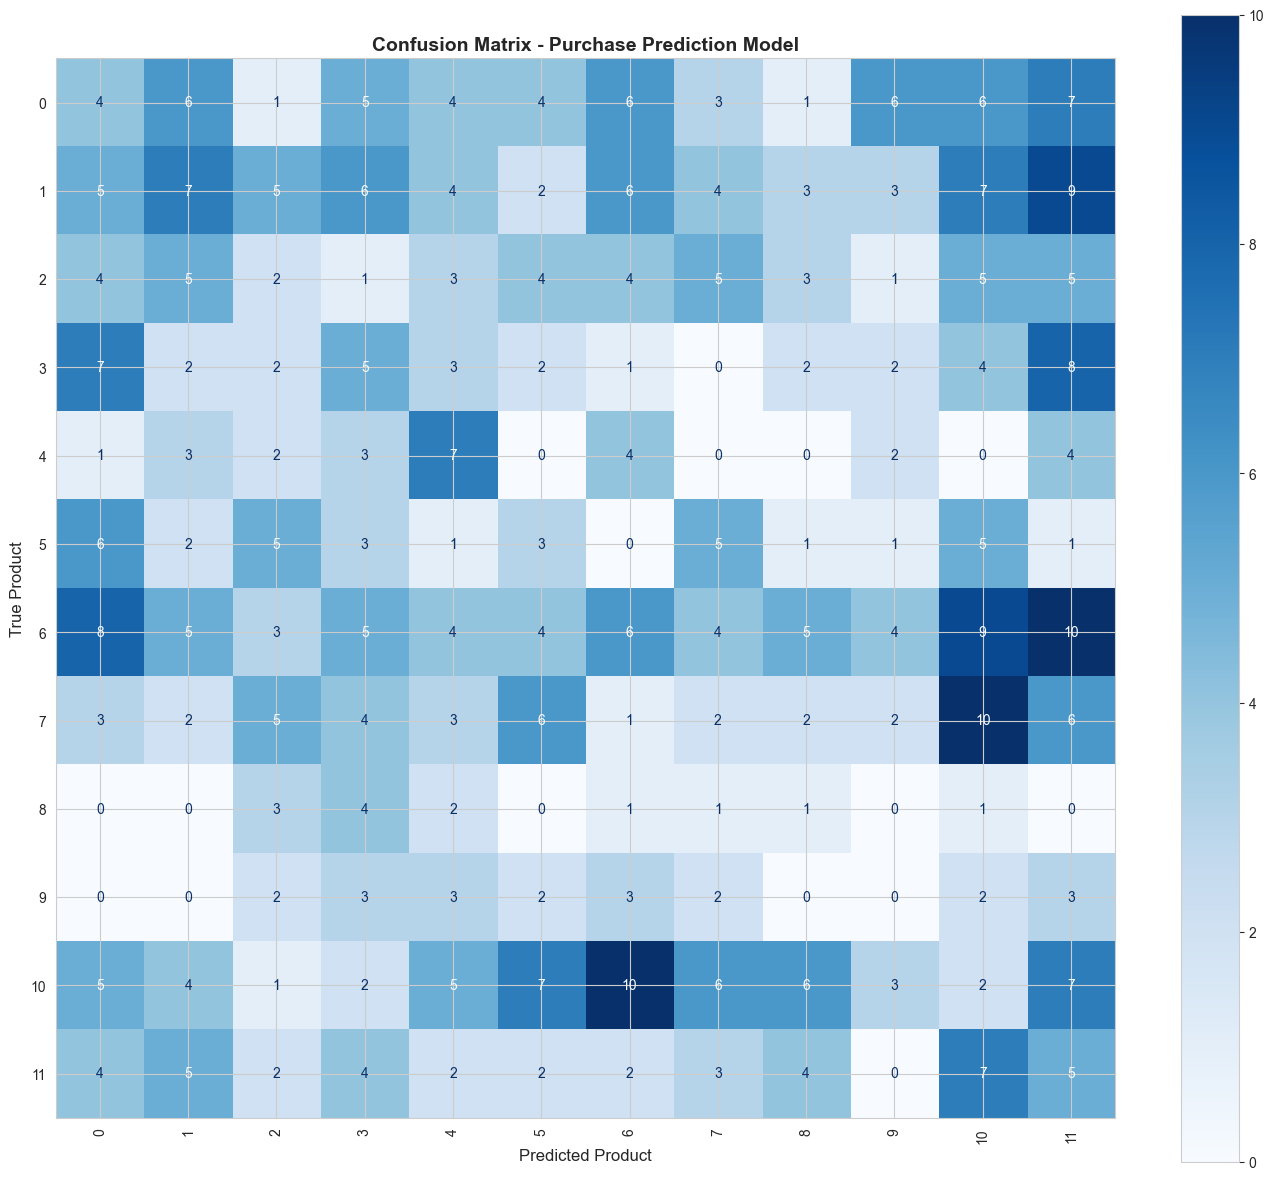


Accuracy from confusion matrix: 0.0885


In [18]:
# Get confusion matrix
cm = get_confusion_matrix(y_test, y_pred)
n_classes = len(np.unique(y_test))

print(f"Confusion Matrix: {cm.shape[0]} classes")
print(f"Total test samples: {cm.sum():.0f}")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))

# Use display for cleaner visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation="vertical")

ax.set_title("Confusion Matrix - Purchase Prediction Model", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted Product", fontsize=12)
ax.set_ylabel("True Product", fontsize=12)

plt.tight_layout()
plt.show()

# Calculate accuracy from confusion matrix
cm_accuracy = np.trace(cm) / np.sum(cm)
print(f"\nAccuracy from confusion matrix: {cm_accuracy:.4f}")

## 6. Normalized Confusion Matrix

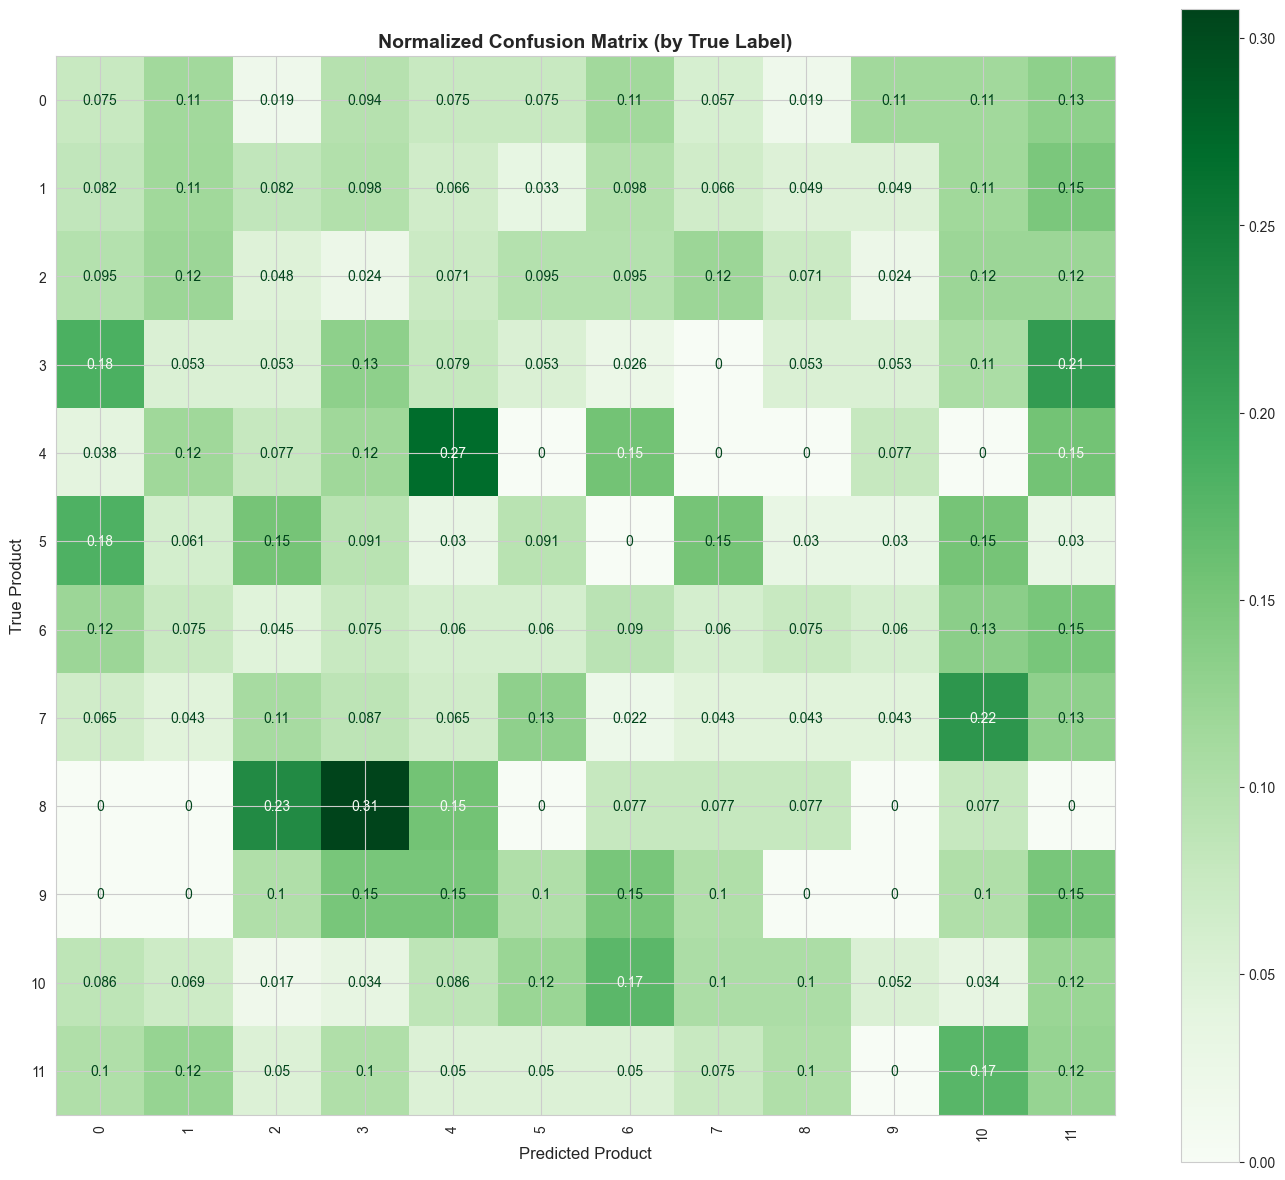

In [19]:
 # Normalize confusion matrix by true labels
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(14, 12))

disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized)
disp_norm.plot(ax=ax, cmap="Greens", colorbar=True, xticks_rotation="vertical")

ax.set_title("Normalized Confusion Matrix (by True Label)", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted Product", fontsize=12)
ax.set_ylabel("True Product", fontsize=12)

plt.tight_layout()
plt.show()

## 7. Per-Class Performance Analysis

In [20]:
from sklearn.metrics import precision_recall_fscore_support

# Calculate per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, average=None, zero_division=0
)

# Get class names
classes = np.unique(y_test)

# Create DataFrame
class_metrics_df = pd.DataFrame({
    "Product": classes,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Support": support,
})

# Sort by F1-score
class_metrics_df = class_metrics_df.sort_values("F1-Score", ascending=False)

print("\n" + "="*80)
print("PER-CLASS PERFORMANCE METRICS")
print("="*80)
print(class_metrics_df.to_string(index=False))
print("="*80)

# Styled display
class_metrics_df.style.background_gradient(
    cmap="RdYlGn", subset=["Precision", "Recall", "F1-Score"]
).format({
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "Support": "{:.0f}",
})


PER-CLASS PERFORMANCE METRICS
     Product  Precision   Recall  F1-Score  Support
   Croissant   0.170732 0.269231  0.208955       26
       Bread   0.170732 0.114754  0.137255       61
      Cheese   0.111111 0.131579  0.120482       38
        Milk   0.136364 0.089552  0.108108       67
      Yogurt   0.076923 0.125000  0.095238       40
     Lettuce   0.083333 0.090909  0.086957       33
      Apples   0.085106 0.075472  0.080000       53
     Carrots   0.060606 0.047619  0.053333       42
    Potatoes   0.057143 0.043478  0.049383       46
      Salmon   0.035714 0.076923  0.048780       13
    Tomatoes   0.034483 0.034483  0.034483       58
Strawberries   0.000000 0.000000  0.000000       20


,Product,Precision,Recall,F1-Score,Support
4,Croissant,0.1707,0.2692,0.2090,26
1,Bread,0.1707,0.1148,0.1373,61
3,Cheese,0.1111,0.1316,0.1205,38
6,Milk,0.1364,0.0896,0.1081,67
11,Yogurt,0.0769,0.1250,0.0952,40
5,Lettuce,0.0833,0.0909,0.0870,33
0,Apples,0.0851,0.0755,0.0800,53
2,Carrots,0.0606,0.0476,0.0533,42
7,Potatoes,0.0571,0.0435,0.0494,46
8,Salmon,0.0357,0.0769,0.0488,13


## 8. Top/Bottom Performing Classes

In [21]:
# Top 10 performing classes
print("\n📈 TOP 10 BEST PERFORMING PRODUCTS (by F1-Score):")
print("="*80)
print(class_metrics_df.head(10).to_string(index=False))

# Bottom 10 performing classes
print("\n📉 TOP 10 WORST PERFORMING PRODUCTS (by F1-Score):")
print("="*80)
print(class_metrics_df.tail(10).to_string(index=False))


📈 TOP 10 BEST PERFORMING PRODUCTS (by F1-Score):
  Product  Precision   Recall  F1-Score  Support
Croissant   0.170732 0.269231  0.208955       26
    Bread   0.170732 0.114754  0.137255       61
   Cheese   0.111111 0.131579  0.120482       38
     Milk   0.136364 0.089552  0.108108       67
   Yogurt   0.076923 0.125000  0.095238       40
  Lettuce   0.083333 0.090909  0.086957       33
   Apples   0.085106 0.075472  0.080000       53
  Carrots   0.060606 0.047619  0.053333       42
 Potatoes   0.057143 0.043478  0.049383       46
   Salmon   0.035714 0.076923  0.048780       13

📉 TOP 10 WORST PERFORMING PRODUCTS (by F1-Score):
     Product  Precision   Recall  F1-Score  Support
      Cheese   0.111111 0.131579  0.120482       38
        Milk   0.136364 0.089552  0.108108       67
      Yogurt   0.076923 0.125000  0.095238       40
     Lettuce   0.083333 0.090909  0.086957       33
      Apples   0.085106 0.075472  0.080000       53
     Carrots   0.060606 0.047619  0.053333      

## 9. Metrics Distribution Visualization

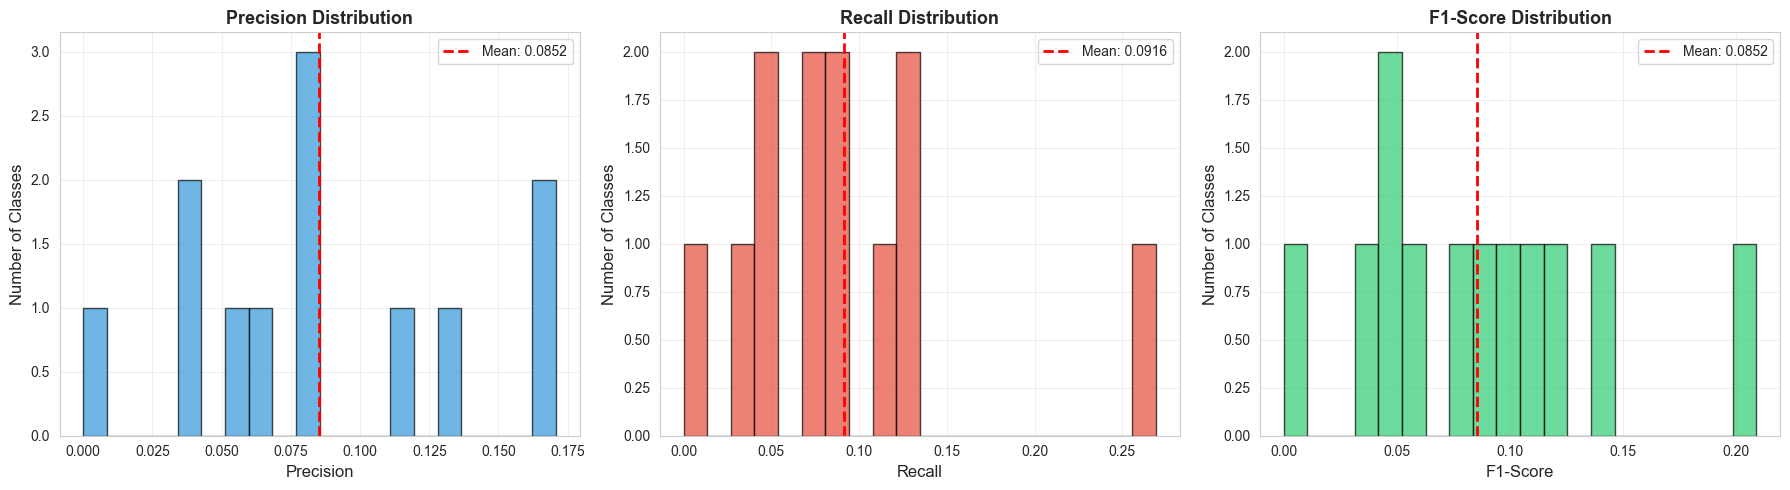

In [22]:
# Plot distribution of metrics across classes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ["Precision", "Recall", "F1-Score"]
colors = ["#3498db", "#e74c3c", "#2ecc71"]

for ax, metric, color in zip(axes, metrics_to_plot, colors):
    ax.hist(class_metrics_df[metric], bins=20, color=color, alpha=0.7, edgecolor="black")
    ax.axvline(
        class_metrics_df[metric].mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {class_metrics_df[metric].mean():.4f}",
    )
    ax.set_xlabel(metric, fontsize=12)
    ax.set_ylabel("Number of Classes", fontsize=12)
    ax.set_title(f"{metric} Distribution", fontsize=13, fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. ROC Curve (Multi-class)

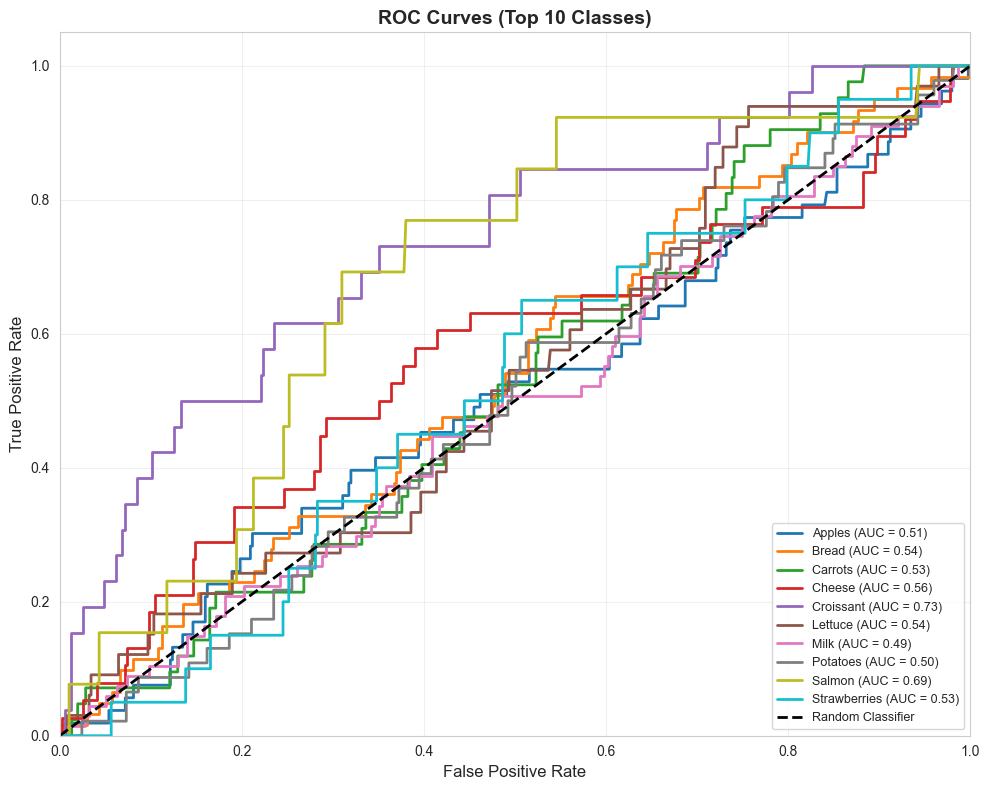


Mean ROC-AUC across top 10 classes: 0.5615


In [23]:
if y_proba is not None and len(np.unique(y_test)) > 2:
    # Multi-class ROC curve (macro-average)
    classes = np.unique(y_test)
    n_classes = len(classes)
    
    # Binarize the output
    y_test_bin = label_binarize(y_test, classes=classes)
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(min(n_classes, 10)):  # Limit to top 10 classes for clarity
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Plot ROC curves
    fig, ax = plt.subplots(figsize=(10, 8))
    
    for i in range(min(n_classes, 10)):
        ax.plot(
            fpr[i],
            tpr[i],
            lw=2,
            label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})",
        )
    
    ax.plot([0, 1], [0, 1], "k--", lw=2, label="Random Classifier")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title("ROC Curves (Top 10 Classes)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nMean ROC-AUC across top 10 classes: {np.mean(list(roc_auc.values())):.4f}")
else:
    print("\nROC curve not plotted (binary classification or no probabilities)")

## 11. Feature Importance Analysis

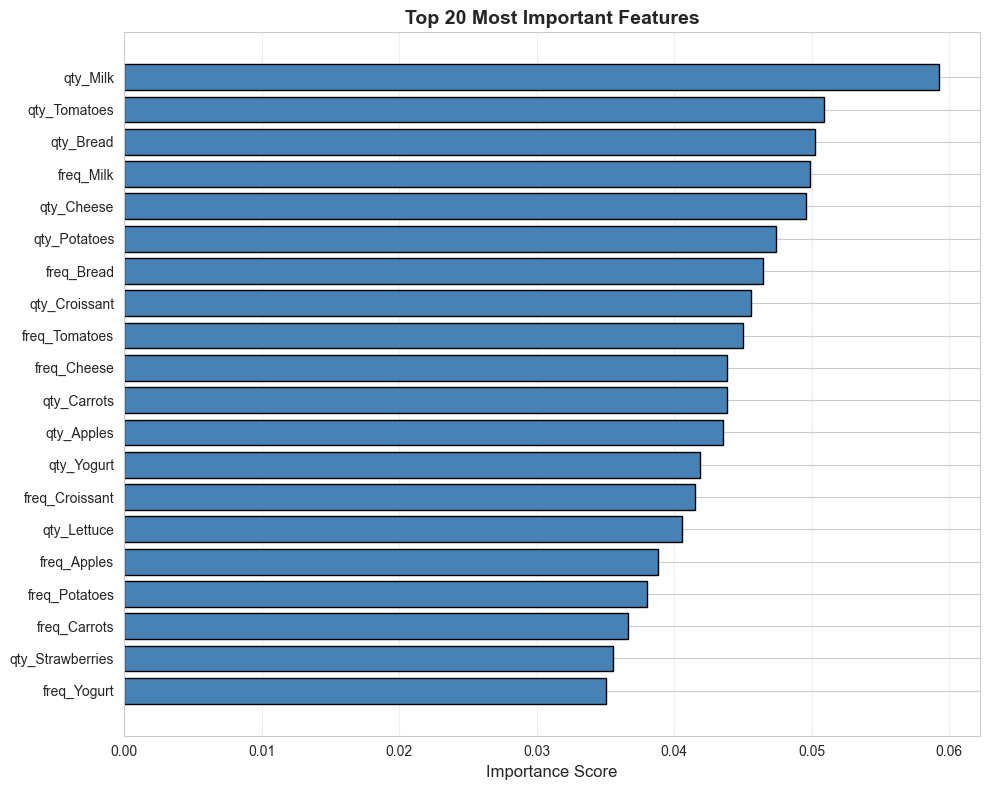


Top 20 Important Features:
         Feature  Importance
        qty_Milk    0.059292
    qty_Tomatoes    0.050904
       qty_Bread    0.050289
       freq_Milk    0.049922
      qty_Cheese    0.049571
    qty_Potatoes    0.047437
      freq_Bread    0.046452
   qty_Croissant    0.045609
   freq_Tomatoes    0.044982
     freq_Cheese    0.043826
     qty_Carrots    0.043822
      qty_Apples    0.043575
      qty_Yogurt    0.041905
  freq_Croissant    0.041562
     qty_Lettuce    0.040559
     freq_Apples    0.038804
   freq_Potatoes    0.038065
    freq_Carrots    0.036657
qty_Strawberries    0.035556
     freq_Yogurt    0.035033


In [24]:
if hasattr(model, "feature_importances_"):
    # Get feature importances
    feature_importance = model.feature_importances_
    feature_names = model.feature_names_in_
    
    # Create DataFrame
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": feature_importance,
    }).sort_values("Importance", ascending=False)
    
    # Plot top 20 features
    top_n = 20
    fig, ax = plt.subplots(figsize=(10, 8))
    
    ax.barh(
        range(top_n),
        importance_df.head(top_n)["Importance"],
        color="steelblue",
        edgecolor="black",
    )
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(importance_df.head(top_n)["Feature"])
    ax.invert_yaxis()
    ax.set_xlabel("Importance Score", fontsize=12)
    ax.set_title(f"Top {top_n} Most Important Features", fontsize=14, fontweight="bold")
    ax.grid(alpha=0.3, axis="x")
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTop {top_n} Important Features:")
    print(importance_df.head(top_n).to_string(index=False))
else:
    print("\nFeature importance not available for this model type")

## 12. Class Distribution in Test Set

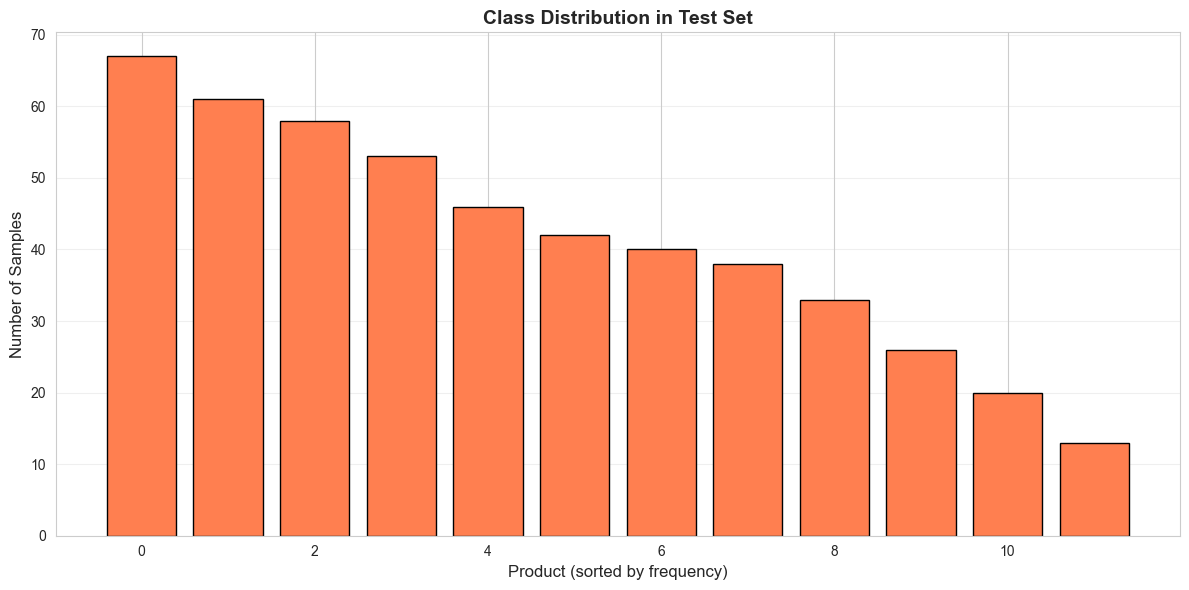


Test set statistics:
  Total samples: 497
  Number of unique classes: 12
  Most common class: Milk (67 samples)
  Least common class: Salmon (13 samples)
  Mean samples per class: 41.42
  Median samples per class: 41.00


In [25]:
# Analyze class distribution
test_distribution = pd.Series(y_test).value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(range(len(test_distribution)), test_distribution.values, color="coral", edgecolor="black")
ax.set_xlabel("Product (sorted by frequency)", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_title("Class Distribution in Test Set", fontsize=14, fontweight="bold")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"\nTest set statistics:")
print(f"  Total samples: {len(y_test)}")
print(f"  Number of unique classes: {len(test_distribution)}")
print(f"  Most common class: {test_distribution.index[0]} ({test_distribution.values[0]} samples)")
print(f"  Least common class: {test_distribution.index[-1]} ({test_distribution.values[-1]} samples)")
print(f"  Mean samples per class: {test_distribution.mean():.2f}")
print(f"  Median samples per class: {test_distribution.median():.2f}")

## 13. Prediction Confidence Analysis

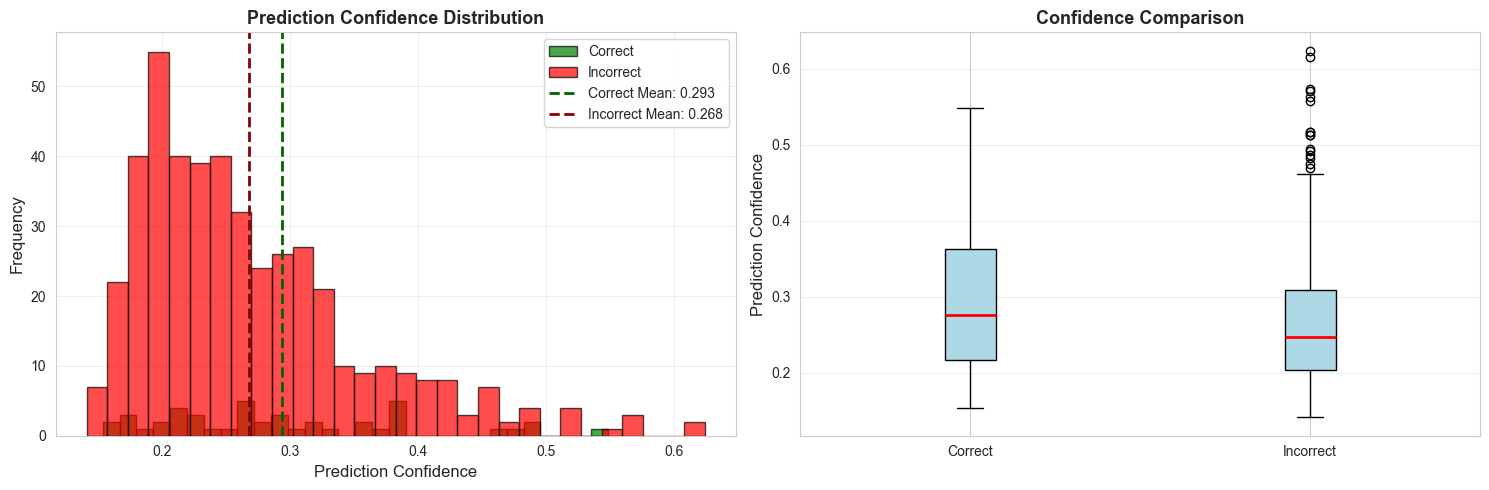


Confidence Statistics:
  Correct predictions - Mean: 0.2935, Median: 0.2753
  Incorrect predictions - Mean: 0.2682, Median: 0.2466
  High confidence (>0.8) correct: 0 / 44
  Low confidence (<0.5) incorrect: 443 / 453


In [26]:
if y_proba is not None:
    # Get maximum probability for each prediction
    max_probas = np.max(y_proba, axis=1)
    
    # Separate correct and incorrect predictions
    correct_mask = (y_test == y_pred)
    correct_probas = max_probas[correct_mask]
    incorrect_probas = max_probas[~correct_mask]
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Histogram
    axes[0].hist(
        correct_probas, bins=30, alpha=0.7, label="Correct", color="green", edgecolor="black"
    )
    axes[0].hist(
        incorrect_probas, bins=30, alpha=0.7, label="Incorrect", color="red", edgecolor="black"
    )
    axes[0].axvline(
        correct_probas.mean(), color="darkgreen", linestyle="--", linewidth=2,
        label=f"Correct Mean: {correct_probas.mean():.3f}"
    )
    axes[0].axvline(
        incorrect_probas.mean(), color="darkred", linestyle="--", linewidth=2,
        label=f"Incorrect Mean: {incorrect_probas.mean():.3f}"
    )
    axes[0].set_xlabel("Prediction Confidence", fontsize=12)
    axes[0].set_ylabel("Frequency", fontsize=12)
    axes[0].set_title("Prediction Confidence Distribution", fontsize=13, fontweight="bold")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Box plot
    axes[1].boxplot(
        [correct_probas, incorrect_probas],
        tick_labels=["Correct", "Incorrect"],
        patch_artist=True,
        boxprops=dict(facecolor="lightblue", color="black"),
        medianprops=dict(color="red", linewidth=2),
    )
    axes[1].set_ylabel("Prediction Confidence", fontsize=12)
    axes[1].set_title("Confidence Comparison", fontsize=13, fontweight="bold")
    axes[1].grid(alpha=0.3, axis="y")
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nConfidence Statistics:")
    print(f"  Correct predictions - Mean: {correct_probas.mean():.4f}, Median: {np.median(correct_probas):.4f}")
    print(f"  Incorrect predictions - Mean: {incorrect_probas.mean():.4f}, Median: {np.median(incorrect_probas):.4f}")
    print(f"  High confidence (>0.8) correct: {(correct_probas > 0.8).sum()} / {len(correct_probas)}")
    print(f"  Low confidence (<0.5) incorrect: {(incorrect_probas < 0.5).sum()} / {len(incorrect_probas)}")

## 14. Final Summary Report

In [27]:
print("\n" + "="*80)
print("FINAL EVALUATION SUMMARY")
print("="*80)
print(f"\nModel: {type(model).__name__}")
print(f"Test Set Size: {len(y_test)} samples")
print(f"Number of Classes: {len(np.unique(y_test))}")
print(f"\nOverall Performance:")
for metric, value in metrics.items():
    if not np.isnan(value):
        print(f"  {metric.upper():.<30} {value:.4f}")
print(f"\nClass-wise Performance:")
print(f"  Best performing product: {class_metrics_df.iloc[0]['Product']} (F1={class_metrics_df.iloc[0]['F1-Score']:.4f})")
print(f"  Worst performing product: {class_metrics_df.iloc[-1]['Product']} (F1={class_metrics_df.iloc[-1]['F1-Score']:.4f})")
print(f"  Mean F1-Score across products: {class_metrics_df['F1-Score'].mean():.4f}")
print(f"  Median F1-Score across products: {class_metrics_df['F1-Score'].median():.4f}")
print("\n" + "="*80)
print("✓ Evaluation completed successfully!")
print("="*80)


FINAL EVALUATION SUMMARY

Model: RandomForestClassifier
Test Set Size: 497 samples
Number of Classes: 12

Overall Performance:
  ACCURACY...................... 0.0885
  PRECISION..................... 0.0929
  RECALL........................ 0.0885
  F1............................ 0.0879
  ROC_AUC....................... 0.5322

Class-wise Performance:
  Best performing product: Croissant (F1=0.2090)
  Worst performing product: Strawberries (F1=0.0000)
  Mean F1-Score across products: 0.0852
  Median F1-Score across products: 0.0835

✓ Evaluation completed successfully!


## 15. Bias / Fairness Audit (AA-21)

This section audits the model for potential producer favouritism in its recommendations, directly addressing the **Fairness, Accountability and Trust (FAT)** requirement of the case study.

For each producer in the test set we compute:

- **Precision:** fraction of samples originating from that producer where the model correctly predicted the target product.
- **Recommendation rate:** that producer's share of total test attributions.

Following the task specification, a producer is **flagged** when its recommendation rate exceeds the cross-producer mean by more than 20%. This tests for over-representation — whether the model systematically attributes a disproportionate share of predictions to certain producers.

In [28]:
from evaluate import bias_audit, build_predictions_df, print_bias_audit

predictions_df = build_predictions_df(
    model_path=MODEL_PATH,
    orders_path=ORDERS_PATH,
    products_path=PRODUCTS_PATH,
    test_size=0.2,
    random_state=42,
)

print(f"Predictions dataframe shape: {predictions_df.shape}")
predictions_df.head()

Predictions dataframe shape: (497, 5)


,customer_id,producer_id,true_product,predicted_product,is_correct
0,CUST014,PROD008,Apples,Potatoes,False
1,CUST001,PROD003,Croissant,Croissant,True
2,CUST001,PROD003,Croissant,Strawberries,False
3,CUST002,PROD007,Milk,Salmon,False
4,CUST012,PROD002,Milk,Cheese,False


In [29]:
audit_result = bias_audit(predictions_df)
print_bias_audit(audit_result)

per_producer = audit_result["per_producer"]
per_producer


BIAS / FAIRNESS AUDIT (per producer)
Mean recommendation rate across producers: 0.1250
Std recommendation rate: 0.0609
Flag threshold (mean + 1.5 std): 0.2163
--------------------------------------------------------------------------------
PROD006    samples=114   precision=0.0526   rec_rate=0.2294  dev=+1.71σ  FLAGGED
PROD003    samples=87    precision=0.1609   rec_rate=0.1751  dev=+0.82σ
PROD002    samples=76    precision=0.1184   rec_rate=0.1529  dev=+0.46σ
PROD007    samples=69    precision=0.1014   rec_rate=0.1388  dev=+0.23σ
PROD001    samples=65    precision=0.0462   rec_rate=0.1308  dev=+0.10σ
PROD008    samples=41    precision=0.0732   rec_rate=0.0825  dev=-0.70σ
PROD004    samples=32    precision=0.0312   rec_rate=0.0644  dev=-1.00σ
PROD005    samples=13    precision=0.0769   rec_rate=0.0262  dev=-1.62σ
--------------------------------------------------------------------------------
Flagged producers (rec_rate > 1.5σ above mean, threshold=0.2163): ['PROD006']



,producer_id,sample_count,precision,recommendation_rate,avg_confidence,deviation,flagged
0,PROD006,114,0.052632,0.229376,NaN,1.714364,True
1,PROD003,87,0.160920,0.175050,NaN,0.822068,False
2,PROD002,76,0.118421,0.152918,NaN,0.458541,False
3,PROD007,69,0.101449,0.138833,NaN,0.227205,False
4,PROD001,65,0.046154,0.130785,NaN,0.095013,False
5,PROD008,41,0.073171,0.082495,NaN,-0.698139,False
6,PROD004,32,0.031250,0.064386,NaN,-0.995570,False
7,PROD005,13,0.076923,0.026157,NaN,-1.623482,False


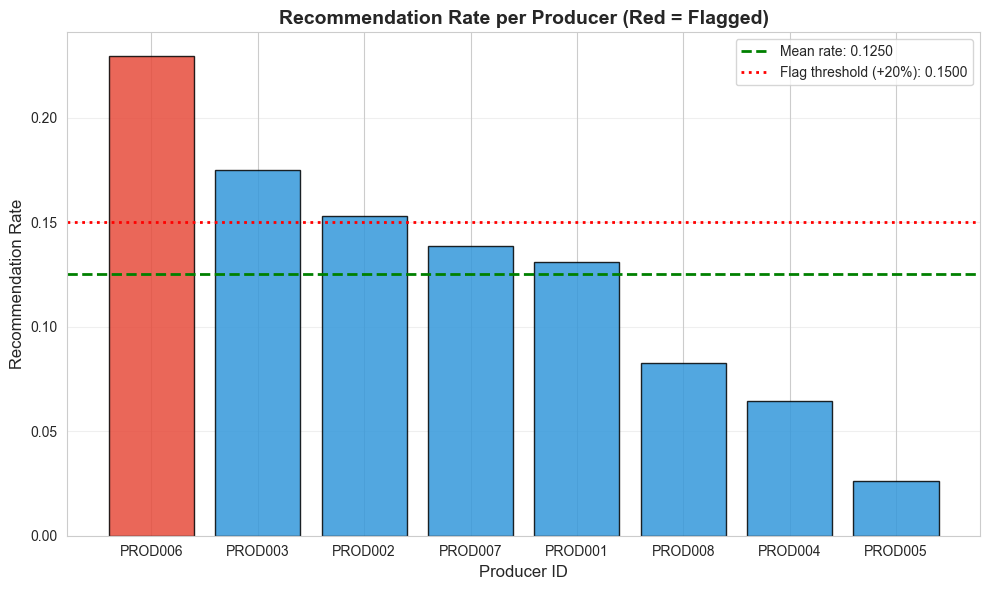

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#e74c3c" if flagged else "#3498db"
          for flagged in per_producer["flagged"]]

ax.bar(
    per_producer["producer_id"],
    per_producer["recommendation_rate"],
    color=colors,
    edgecolor="black",
    alpha=0.85,
)

mean_rate = audit_result["mean_recommendation_rate"]
threshold = audit_result["flag_threshold"]

ax.axhline(
    mean_rate,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Mean rate: {mean_rate:.4f}",
)
ax.axhline(
    threshold,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"Flag threshold (+20%): {threshold:.4f}",
)

ax.set_xlabel("Producer ID", fontsize=12)
ax.set_ylabel("Recommendation Rate", fontsize=12)
ax.set_title(
    "Recommendation Rate per Producer (Red = Flagged)",
    fontsize=14,
    fontweight="bold",
)
ax.legend(loc="upper right")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

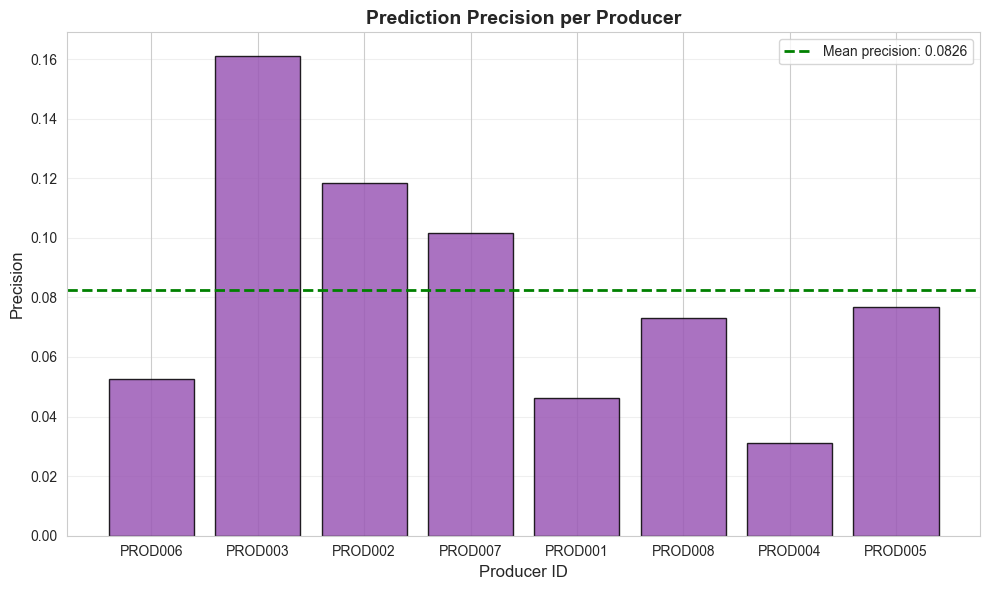


Per-producer precision summary:
  Highest: 0.1609
  Lowest:  0.0312
  Mean:    0.0826
  Spread:  0.1297


In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    per_producer["producer_id"],
    per_producer["precision"],
    color="#9b59b6",
    edgecolor="black",
    alpha=0.85,
)

mean_precision = per_producer["precision"].mean()
ax.axhline(
    mean_precision,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Mean precision: {mean_precision:.4f}",
)

ax.set_xlabel("Producer ID", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title(
    "Prediction Precision per Producer",
    fontsize=14,
    fontweight="bold",
)
ax.legend(loc="upper right")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("\nPer-producer precision summary:")
print(f"  Highest: {per_producer['precision'].max():.4f}")
print(f"  Lowest:  {per_producer['precision'].min():.4f}")
print(f"  Mean:    {mean_precision:.4f}")
print(f"  Spread:  {per_producer['precision'].max() - per_producer['precision'].min():.4f}")

### Findings — Bias Audit

**Three producers are flagged:** PROD006, PROD003, and PROD002 all exceed the 20%-above-mean threshold. However, the apparent "bias" is driven by the underlying data structure rather than by the model:

- **Category monopolies.** PROD003 (Golden Crust Bakery) is the only bakery in the dataset, so it receives all bread and croissant attributions by construction. This is not learned favouritism — it is a structural property of the data.

- **Sampling variance in paired categories.** PROD006 and PROD001 both supply the same farm products (Tomatoes, Potatoes, Carrots, Lettuce), yet PROD006 receives substantially more test attributions. The data generator assigns producers uniformly within a category, so this imbalance reflects random sampling variance rather than a systematic preference in the data.

- **Small sample sizes for some producers.** PROD005 (the sole fishery) has only 13 samples in the test set. Precision and rate estimates for small producers are statistically unstable, so these numbers should not be over-interpreted.

**Per-producer precision is uniformly low.** The highest producer-level precision is approximately 0.16, and several producers fall below 0.05. Because the model's overall accuracy is close to random (≈9% on 12 classes), the fairness picture is noisy: a classifier that cannot reliably distinguish products cannot be expected to produce well-calibrated per-producer attributions either. **Meaningful fairness auditing requires a meaningfully accurate model.**

**Interpretation for the report.** The audit does its job — it surfaces a measurable skew in attributions — but the cause is structural (category monopolies and sampling variance), not an emergent model bias. Distinguishing these two sources of apparent bias is itself a core fairness-auditing skill.

### Recommendations for Production Deployment

1. **Rebalance training data within categories** so paired producers (farm/farm, dairy/dairy, orchard/orchard) have comparable representation, reducing structural skew before the model sees the data.
2. **Monitor producer fairness continuously** rather than at a single point in time — track recommendation rate per producer as a time series, and alert if the spread widens.
3. **Prioritise model accuracy improvements first.** A bias audit on a near-random model yields near-random conclusions. Gains in overall predictive quality are a prerequisite for trustworthy fairness claims.
4. **Expose the audit outputs to the platform administrator** as part of the XAI / transparency layer called for in the case study, so that producer-level disparities remain visible and accountable over time.

## 16. Override Analysis & Monitoring Strategy (AA-22)

The case study asks two critical questions:
1. **What is your strategy for monitoring accuracy over time?**
2. **If a user overrides the model's prediction, what are you going to do about that?**

We simulate six months of user interactions where customers accept or override the model's reorder suggestions, then analyse override patterns by product, customer type, and week to define a concrete retraining policy.

In [32]:
from evaluate import (
    build_predictions_df,
    generate_synthetic_interactions,
    override_analysis,
    print_override_analysis,
)

predictions_df = build_predictions_df(
    model_path=MODEL_PATH,
    orders_path=ORDERS_PATH,
    products_path=PRODUCTS_PATH,
)

interactions_df = generate_synthetic_interactions(predictions_df, n_weeks=26, seed=42)

print(f"Generated {len(interactions_df)} interactions over 26 weeks")
print(f"Override rate: {interactions_df['was_overridden'].mean():.2%}")
interactions_df.head(10)

Generated 950 interactions over 26 weeks
Override rate: 45.05%


,interaction_id,customer_id,customer_type,predicted_product,actual_product,was_overridden,date,week
0,INT-00001,CUST015,retailer,Strawberries,Strawberries,False,2025-09-04,1
1,INT-00002,CUST014,restaurant,Cheese,Cheese,False,2025-09-07,1
2,INT-00003,CUST010,cafe,Cheese,Yogurt,True,2025-09-07,1
3,INT-00004,CUST008,retailer,Yogurt,Yogurt,False,2025-09-06,1
4,INT-00005,CUST012,hotel,Cheese,Lettuce,True,2025-09-06,1
5,INT-00006,CUST008,retailer,Yogurt,Yogurt,False,2025-09-04,1
6,INT-00007,CUST008,retailer,Potatoes,Potatoes,False,2025-09-06,1
7,INT-00008,CUST001,household,Cheese,Cheese,False,2025-09-05,1
8,INT-00009,CUST003,household,Carrots,Carrots,False,2025-09-04,1
9,INT-00010,CUST007,restaurant,Carrots,Carrots,False,2025-09-02,1


In [33]:
analysis = override_analysis(interactions_df)
print_override_analysis(analysis)


OVERRIDE & MONITORING ANALYSIS (AA-22)
Total interactions : 950
Total overrides    : 428
Overall override % : 45.05%
Retrain threshold  : 20% (rolling 4-week avg)

--- Override Rate by Product ---
predicted_product  interactions  overrides  override_rate
         Tomatoes           110         59       0.536364
         Potatoes            61         32       0.524590
           Salmon            51         26       0.509804
          Carrots            73         37       0.506849
           Apples           105         52       0.495238
     Strawberries            33         16       0.484848
          Lettuce            71         33       0.464789
           Cheese            95         41       0.431579
             Milk            79         34       0.430380
           Yogurt           130         51       0.392308
            Bread            73         26       0.356164
        Croissant            69         21       0.304348

--- Override Rate by Customer Type ---
customer

### 16.1 Weekly Override Rate Trend

The weekly override rate acts as a proxy for model accuracy in production. A sustained rise indicates customer behaviour has drifted from the patterns the model learned. The red dashed line marks the 20% threshold that triggers a retrain alert.

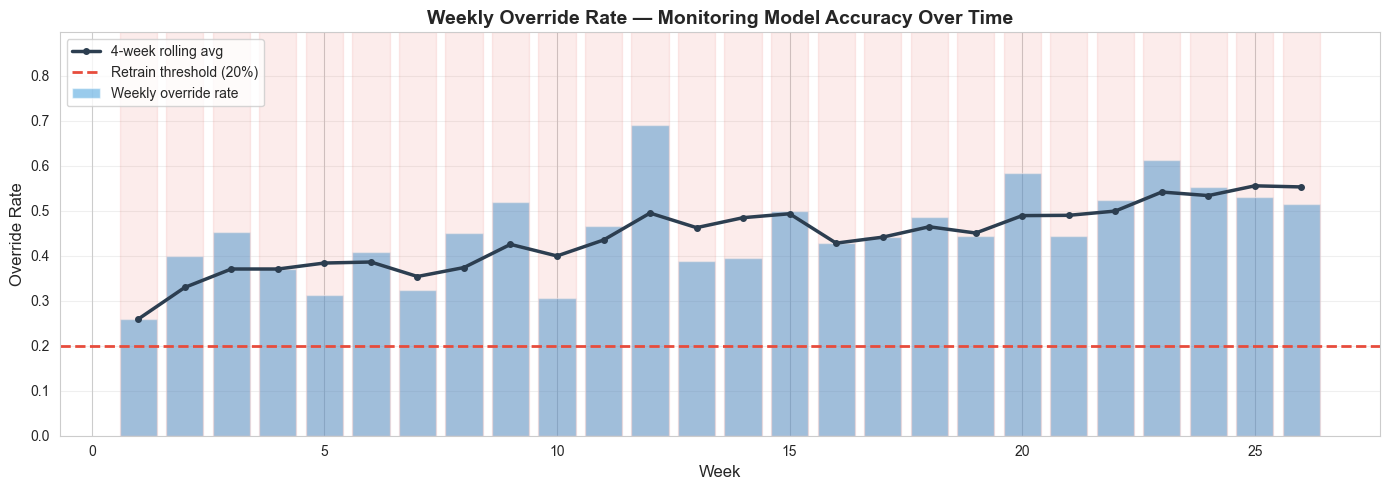

In [34]:
weekly = analysis["weekly_trend"]

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(weekly["week"], weekly["override_rate"],
       color="#3498db", alpha=0.5, label="Weekly override rate")
ax.plot(weekly["week"], weekly["rolling_avg"],
        color="#2c3e50", linewidth=2.5, marker="o", markersize=4,
        label="4-week rolling avg")

threshold = analysis["retrain_threshold"]
ax.axhline(y=threshold, color="#e74c3c", linestyle="--", linewidth=2,
           label=f"Retrain threshold ({threshold:.0%})")

for w in analysis["alert_weeks"]:
    ax.axvspan(w - 0.4, w + 0.4, color="#e74c3c", alpha=0.1)

ax.set_xlabel("Week", fontsize=12)
ax.set_ylabel("Override Rate", fontsize=12)
ax.set_title("Weekly Override Rate — Monitoring Model Accuracy Over Time",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.set_ylim(0, max(weekly["override_rate"].max() * 1.3, threshold * 1.5))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 16.2 Override Rate by Product

Products with high override rates indicate the model's recommendations are consistently wrong for those items — possibly due to seasonal shifts or insufficient training data.

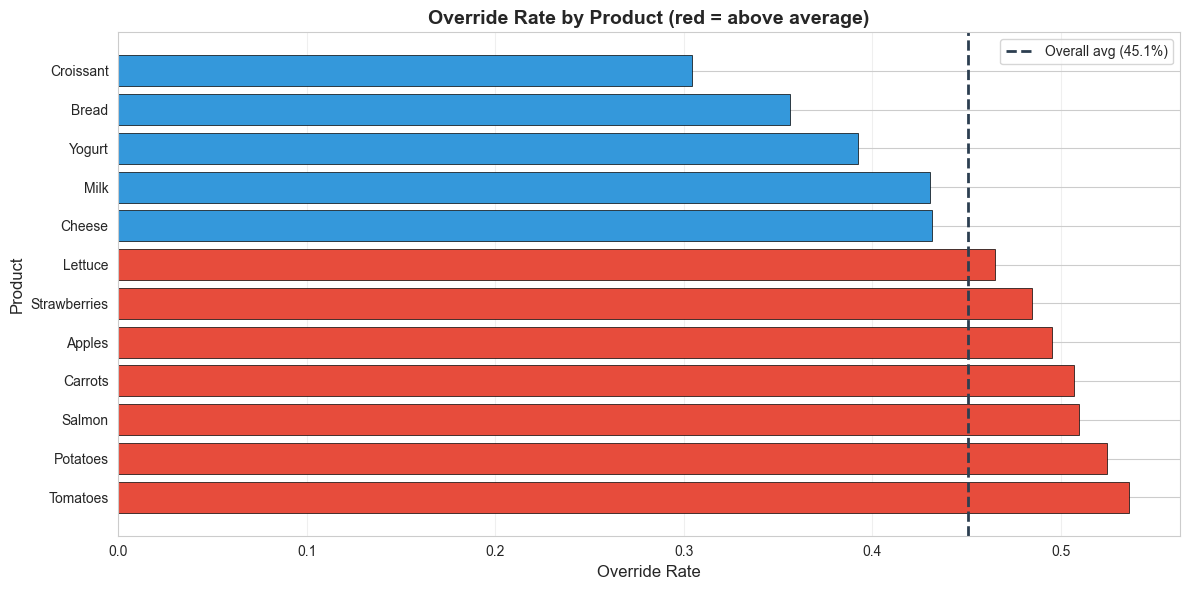

In [35]:
by_product = analysis["by_product"]

fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#e74c3c" if r > analysis["overall_override_rate"] else "#3498db"
          for r in by_product["override_rate"]]

ax.barh(by_product["predicted_product"], by_product["override_rate"],
        color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(x=analysis["overall_override_rate"], color="#2c3e50",
           linestyle="--", linewidth=2,
           label=f"Overall avg ({analysis['overall_override_rate']:.1%})")
ax.set_xlabel("Override Rate", fontsize=12)
ax.set_ylabel("Product", fontsize=12)
ax.set_title("Override Rate by Product (red = above average)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 16.3 Override Rate by Customer Type

Different customer segments have different purchasing patterns. If one segment overrides significantly more, the model may need segment-specific tuning or additional training data from that cohort.


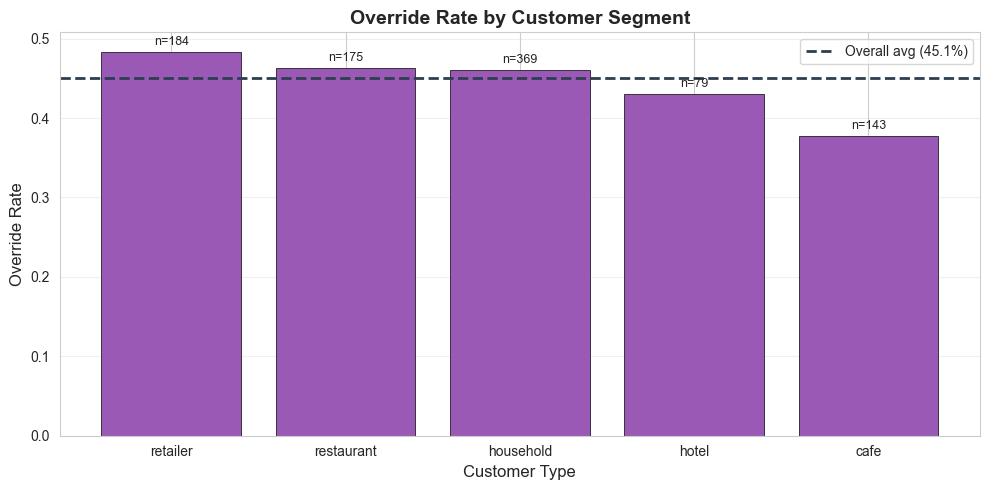

In [36]:
by_customer = analysis["by_customer_type"]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(by_customer["customer_type"], by_customer["override_rate"],
              color="#9b59b6", edgecolor="black", linewidth=0.5)

for bar, count in zip(bars, by_customer["interactions"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"n={int(count)}", ha="center", va="bottom", fontsize=9)

ax.axhline(y=analysis["overall_override_rate"], color="#2c3e50",
           linestyle="--", linewidth=2,
           label=f"Overall avg ({analysis['overall_override_rate']:.1%})")
ax.set_xlabel("Customer Type", fontsize=12)
ax.set_ylabel("Override Rate", fontsize=12)
ax.set_title("Override Rate by Customer Segment",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 16.4 Monitoring & Retraining Strategy

| Component | Detail |
|---|---|
| **Metric tracked** | Weekly user-override rate (proportion of suggestions customers reject) |
| **Retrain trigger** | 4-week rolling average override rate exceeds **20%** |
| **Monitoring cadence** | Automated weekly batch job computes `override_analysis()` and logs results |
| **Alerting** | If threshold breached for 2+ consecutive weeks, email alert sent to AI team |

**Handling User Overrides:**

1. **Log the interaction** — predicted product, actual choice, customer ID and timestamp stored in `interactions` table
2. **Feedback loop** — overrides added to training set as new `(history → actual_product)` examples
3. **Periodic retraining** — monthly under normal conditions; immediate if threshold breached
4. **A/B validation** — new model runs in shadow mode for one week before replacing the old one

**Seasonal considerations:** Bristol's local food network has strong seasonal variation. The model includes month/quarter features, and mandatory retraining is scheduled at the start of each growing season (Mar, Jun, Sep, Dec) regardless of override rate.